In [1]:
#Enable GPU P100

**Used the same data given in the competition** 
The data is in this [link](https://www.kaggle.com/datasets/sanjidx/fragments-of-feeling) ,
Version 2 has the hidden test set as well 

https://www.kaggle.com/code/sanjidx/final-notebook-fragment-of-feeling4aca8007ef  To view the full notebook

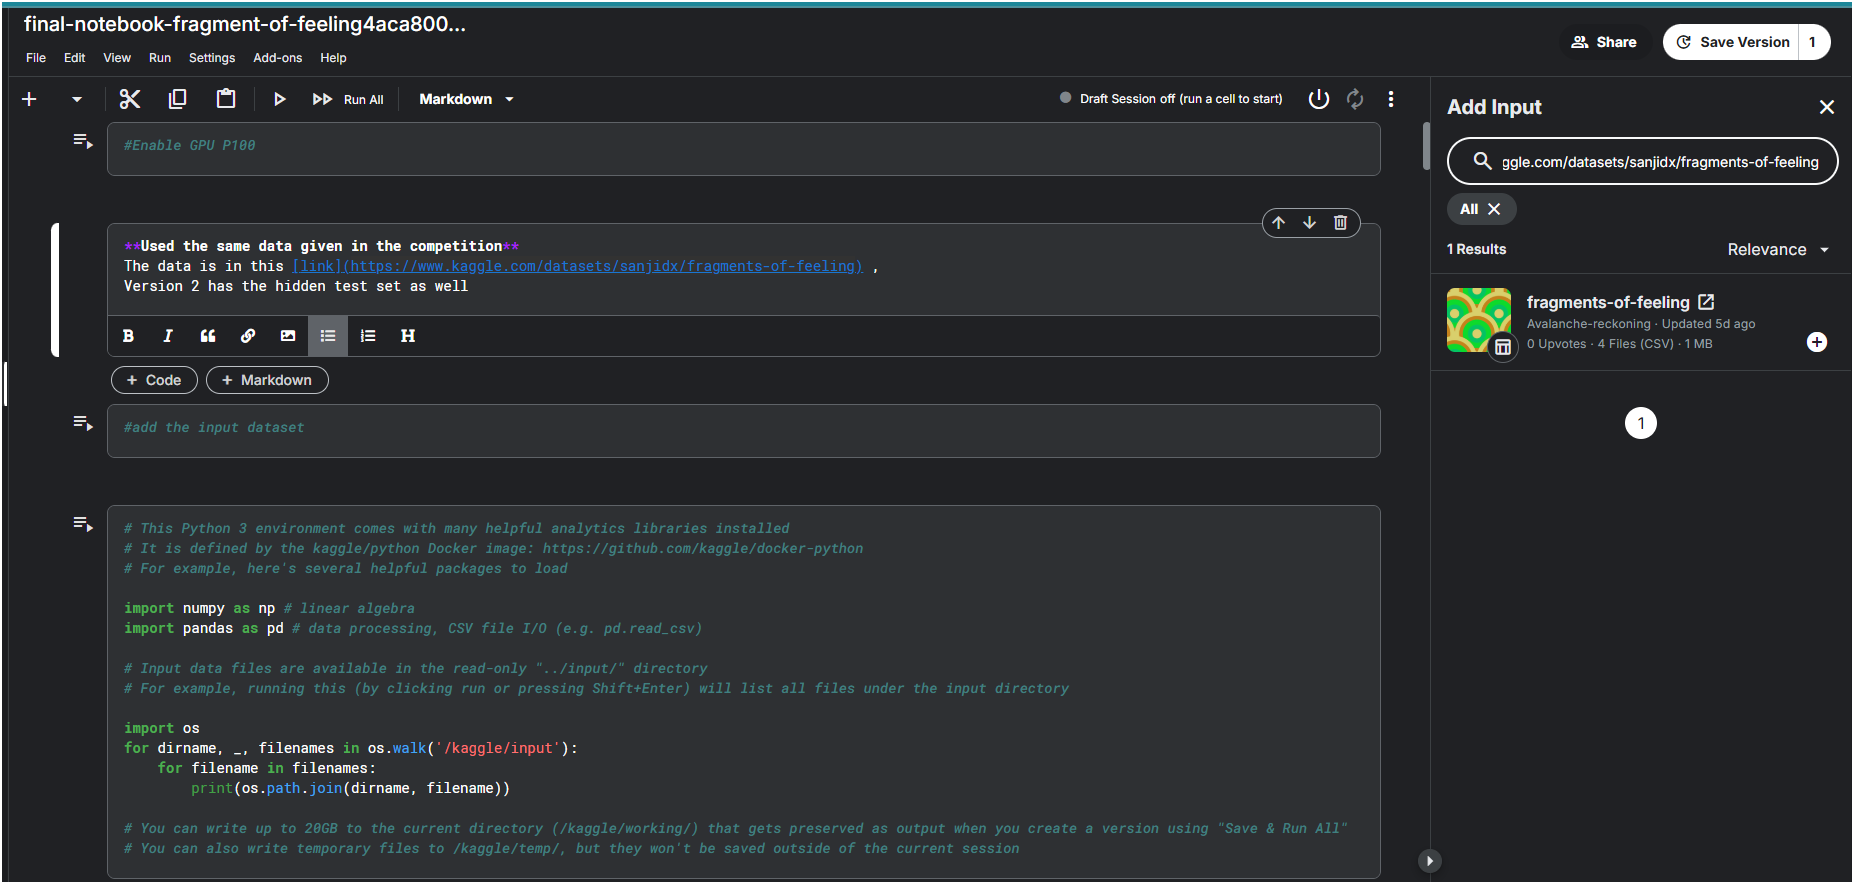

In [2]:
#add the input dataset

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fragments-of-feeling/test_emotions_no_labels.csv
/kaggle/input/fragments-of-feeling/fragments-of-feeling/sample_submission.csv
/kaggle/input/fragments-of-feeling/fragments-of-feeling/train_emotions.csv
/kaggle/input/fragments-of-feeling/fragments-of-feeling/val_emotions_no_labels.csv


In [4]:
!python --version
!pip list
!nvidia-smi

Python 3.11.13
Package                               Version             Editable project location
------------------------------------- ------------------- -------------------------
absl-py                               1.4.0
accelerate                            1.8.1
aiofiles                              22.1.0
aiohappyeyeballs                      2.6.1
aiohttp                               3.12.13
aiosignal                             1.3.2
aiosqlite                             0.21.0
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.11.1
alembic                               1.16.2
altair                                5.5.0
annotated-types                       0.7.0
annoy                                 1.17.3
ansicolors                            1.1.8
antlr4-python3-runtime                4.9.3
anyio                                 4.9.0
argon2-cffi      

In [5]:
!pip freeze > requirements.txt

In [ ]:
# === SETUP AND CONFIGURATION ===
!pip install -q textstat safetensors
import random
import pandas as pd
import numpy as np
import torch
import gc
import re
import string
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textstat import flesch_reading_ease, flesch_kincaid_grade
from safetensors.torch import save_file
import warnings
warnings.filterwarnings('ignore')

# Note: In a typical Kaggle environment, these packages and nltk data
# are pre-installed. The lines to download them can be omitted.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_name = "microsoft/deberta-v3-large"
# Increased sequence length to capture more context
max_seq_length = 512
n_splits = 5

# --- REPRODUCIBILITY ---
# Set a single seed for all random operations to ensure the results are
# identical every time the script is run.
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)
print(f"🌱 Random seed set to {seed_value} for all operations.")

# === DATA LOADING ===
print("Loading datasets...")
try:
    train_df = pd.read_csv('/kaggle/input/fragments-of-feeling/fragments-of-feeling/train_emotions.csv')
    val_df = pd.read_csv('/kaggle/input/fragments-of-feeling/fragments-of-feeling/val_emotions_no_labels.csv')
    test_df = pd.read_csv('/kaggle/input/fragments-of-feeling/test_emotions_no_labels.csv')
    sample_submission_df = pd.read_csv('/kaggle/input/fragments-of-feeling/fragments-of-feeling/sample_submission.csv')
    print("Datasets loaded successfully.")
    print(f"Training data shape: {train_df.shape}")
    print(f"Validation data shape: {test_df.shape}")
    print(f"Sample submission shape: {sample_submission_df.shape}")
except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    # For local testing, you can load from local files
    try:
        train_df = pd.read_csv('train_emotions.csv')
        test_df = pd.read_csv('test_emotions_no_labels.csv')
        sample_submission_df = pd.read_csv('sample_submission.csv')
        print("Local datasets loaded successfully.")
    except:
        print("Could not load datasets from local or Kaggle paths")
        raise

# === COMBINE TITLE AND SENTENCE COLUMNS ===
print("Combining 'title' and 'sentence' columns into a new 'full_text' column...")
# Handle potential NaN values by filling with empty strings
train_df['full_text'] = train_df['title'].fillna('') + ' ' + train_df['sentence'].fillna('')
test_df['full_text'] = test_df['title'].fillna('') + ' ' + test_df['sentence'].fillna('')
print(f"Combined training data shape: {train_df.shape}")
print(f"Combined validation data shape: {test_df.shape}")

# === ENHANCED FEATURE EXTRACTION CLASS ===
class TextFeatureExtractor:
    """Advanced feature extraction for text analysis"""

    def __init__(self):
        self.sia = SentimentIntensityAnalyzer()
        self.stop_words = set(stopwords.words('english'))

        # Enhanced emotion-specific word lists with more comprehensive keywords
        self.emotion_keywords = {
            'sadness': ['sad', 'cry', 'tear', 'grief', 'sorrow', 'melancholy', 'blue', 'down', 'depressed'],
            'hopelessness': ['hopeless', 'despair', 'futile', 'pointless', 'useless', 'surrender', 'give up'],
            'loneliness': ['alone', 'lonely', 'isolated', 'solitary', 'abandoned', 'forsaken'],
            'anger': ['angry', 'mad', 'furious', 'rage', 'hate', 'irritated', 'annoyed', 'pissed'],
            'worthlessness': ['worthless', 'useless', 'failure', 'inadequate', 'pathetic', 'loser'],
            'suicide intent': ['suicide', 'kill myself', 'end it', 'die', 'death', 'finish'],
            'emptiness': ['empty', 'void', 'hollow', 'numb', 'blank', 'nothing'],
            'brain dysfunction': ['confused', 'foggy', 'unclear', 'mixed up', 'disoriented', 'scattered']
        }

        # Add positive emotion keywords for contrast
        self.positive_keywords = [
            'happy', 'joy', 'excited', 'love', 'grateful', 'blessed', 'amazing',
            'wonderful', 'fantastic', 'great', 'good', 'excellent', 'perfect',
            'awesome', 'brilliant', 'fabulous', 'marvelous', 'outstanding'
        ]

    def extract_basic_features(self, text):
        """Extract basic text statistics with enhanced features"""
        if pd.isna(text) or not text.strip():
            return {f'basic_{key}': 0 for key in [
                'char_count', 'word_count', 'sentence_count', 'avg_word_length',
                'exclamation_count', 'question_count', 'comma_count', 'period_count',
                'punctuation_ratio', 'uppercase_ratio', 'title_word_count',
                'flesch_reading_ease', 'flesch_kincaid_grade', 'short_words_ratio',
                'long_words_ratio', 'capital_words_count'
            ]}

        features = {}
        text_str = str(text)
        words = text_str.split()

        # Basic length features
        features['basic_char_count'] = len(text_str)
        features['basic_word_count'] = len(words)
        features['basic_sentence_count'] = len(text_str.split('.'))
        features['basic_avg_word_length'] = np.mean([len(word) for word in words]) if words else 0

        # Enhanced word length analysis
        if words:
            features['basic_short_words_ratio'] = sum(1 for word in words if len(word) <= 3) / len(words)
            features['basic_long_words_ratio'] = sum(1 for word in words if len(word) >= 7) / len(words)
        else:
            features['basic_short_words_ratio'] = 0
            features['basic_long_words_ratio'] = 0

        # Punctuation features
        features['basic_exclamation_count'] = text_str.count('!')
        features['basic_question_count'] = text_str.count('?')
        features['basic_comma_count'] = text_str.count(',')
        features['basic_period_count'] = text_str.count('.')
        features['basic_punctuation_ratio'] = sum([text_str.count(p) for p in string.punctuation]) / len(text_str) if len(text_str) > 0 else 0

        # Case features
        features['basic_uppercase_ratio'] = sum(1 for c in text_str if c.isupper()) / len(text_str) if len(text_str) > 0 else 0
        features['basic_title_word_count'] = sum(1 for word in words if word.istitle())
        features['basic_capital_words_count'] = sum(1 for word in words if word.isupper())

        # Readability features
        try:
            features['basic_flesch_reading_ease'] = flesch_reading_ease(text_str)
            features['basic_flesch_kincaid_grade'] = flesch_kincaid_grade(text_str)
        except:
            features['basic_flesch_reading_ease'] = 0
            features['basic_flesch_kincaid_grade'] = 0

        return features

    def extract_sentiment_features(self, text):
        """Extract sentiment-based features with enhanced analysis"""
        if pd.isna(text) or not text.strip():
            return {f'sentiment_{key}': 0 for key in [
                'compound', 'positive', 'negative', 'neutral', 'intensity',
                'is_positive', 'is_negative', 'is_neutral', 'positive_words_count',
                'sentiment_variance'
            ]}

        text_str = str(text)

        # VADER sentiment scores
        scores = self.sia.polarity_scores(text_str)

        features = {
            'sentiment_compound': scores['compound'],
            'sentiment_positive': scores['pos'],
            'sentiment_negative': scores['neg'],
            'sentiment_neutral': scores['neu']
        }

        # Enhanced sentiment analysis
        features['sentiment_intensity'] = abs(scores['compound'])
        features['sentiment_is_positive'] = 1 if scores['compound'] > 0.1 else 0
        features['sentiment_is_negative'] = 1 if scores['compound'] < -0.1 else 0
        features['sentiment_is_neutral'] = 1 if abs(scores['compound']) <= 0.1 else 0

        # Count positive words
        words = text_str.lower().split()
        features['sentiment_positive_words_count'] = sum(1 for word in words if word in self.positive_keywords)

        # Sentiment variance (analyzing sentences separately)
        sentences = text_str.split('.')
        if len(sentences) > 1:
            sentence_scores = [self.sia.polarity_scores(sent)['compound'] for sent in sentences if sent.strip()]
            features['sentiment_variance'] = np.var(sentence_scores) if sentence_scores else 0
        else:
            features['sentiment_variance'] = 0

        return features

    def extract_emotion_keywords(self, text):
        """Extract emotion-specific keyword features with enhanced analysis"""
        if pd.isna(text) or not text.strip():
            base_features = {}
            for emotion in self.emotion_keywords.keys():
                base_features[f'emotion_{emotion.replace(" ", "_")}_count'] = 0
                base_features[f'emotion_{emotion.replace(" ", "_")}_present'] = 0
                base_features[f'emotion_{emotion.replace(" ", "_")}_ratio'] = 0
            base_features['emotion_total_keywords'] = 0
            base_features['emotion_diversity_score'] = 0
            return base_features

        features = {}
        text_lower = str(text).lower()
        words = text_lower.split()
        total_words = len(words)

        emotion_counts = {}
        for emotion, keywords in self.emotion_keywords.items():
            # Count exact matches and partial matches
            exact_count = sum(1 for keyword in keywords if keyword in text_lower)

            # Count individual word matches
            word_matches = sum(1 for word in words for keyword in keywords if word == keyword)

            # Use the higher count
            count = max(exact_count, word_matches)

            emotion_key = emotion.replace(" ", "_")
            features[f'emotion_{emotion_key}_count'] = count
            features[f'emotion_{emotion_key}_present'] = 1 if count > 0 else 0
            features[f'emotion_{emotion_key}_ratio'] = count / total_words if total_words > 0 else 0

            emotion_counts[emotion] = count

        # Total emotion keywords
        features['emotion_total_keywords'] = sum(emotion_counts.values())

        # Emotion diversity (how many different emotion types are present)
        emotions_present = sum(1 for count in emotion_counts.values() if count > 0)
        features['emotion_diversity_score'] = emotions_present / len(self.emotion_keywords)

        return features

    def extract_linguistic_features(self, text):
        """Extract linguistic and stylistic features with enhanced analysis"""
        if pd.isna(text) or not text.strip():
            return {f'linguistic_{key}': 0 for key in [
                'first_person_count', 'second_person_count', 'third_person_count',
                'first_person_ratio', 'unique_word_ratio', 'repeated_words',
                'negation_count', 'extreme_word_count', 'stopwords_ratio',
                'avg_sentence_length', 'ellipsis_count', 'all_caps_words'
            ]}

        features = {}
        text_str = str(text)

        # Enhanced personal pronouns with more comprehensive lists
        first_person = [
            'i', "i'm", "i've", "i'll", "i'd", 'me', 'my', 'mine', 'myself',
            'i am', 'i was', 'i have', 'i had', 'i will', 'i would', 'i can', 'i could'
        ]
        second_person = [
            'you', 'your', 'yours', 'yourself', 'you are', 'you were',
            'you have', 'you had', 'you will', 'you would'
        ]
        third_person = [
            'he', 'she', 'it', 'they', 'him', 'her', 'them', 'his', 'hers', 'their',
            'he is', 'she is', 'they are', 'he was', 'she was', 'they were'
        ]

        words = text_str.lower().split()
        total_words = len(words)

        # Count pronouns
        features['linguistic_first_person_count'] = sum(1 for word in words if word in first_person)
        features['linguistic_second_person_count'] = sum(1 for word in words if word in second_person)
        features['linguistic_third_person_count'] = sum(1 for word in words if word in third_person)

        # Pronoun ratios
        features['linguistic_first_person_ratio'] = features['linguistic_first_person_count'] / total_words if total_words > 0 else 0

        # Word repetition and diversity
        word_counts = Counter(words)
        features['linguistic_unique_word_ratio'] = len(word_counts) / total_words if total_words > 0 else 0
        features['linguistic_repeated_words'] = sum(1 for count in word_counts.values() if count > 1)

        # Enhanced negation words
        negation_words = [
            'not', 'no', 'never', 'nothing', 'nobody', 'nowhere', "don't", "won't",
            "can't", "shouldn't", "wouldn't", "couldn't", "isn't", "aren't", "wasn't",
            "weren't", "hasn't", "haven't", "hadn't", "neither", "nor", "none"
        ]
        features['linguistic_negation_count'] = sum(1 for word in words if word in negation_words)

        # Enhanced extreme/intensity words
        extreme_words = [
            'very', 'extremely', 'totally', 'completely', 'absolutely', 'really', 'quite',
            'incredibly', 'amazingly', 'utterly', 'entirely', 'purely', 'highly',
            'tremendously', 'enormously', 'exceptionally', 'remarkably'
        ]
        features['linguistic_extreme_word_count'] = sum(1 for word in words if word in extreme_words)

        # Stopwords ratio
        features['linguistic_stopwords_ratio'] = sum(1 for word in words if word in self.stop_words) / total_words if total_words > 0 else 0

        # Sentence-level features
        sentences = [s.strip() for s in text_str.split('.') if s.strip()]
        if sentences:
            sentence_lengths = [len(sent.split()) for sent in sentences]
            features['linguistic_avg_sentence_length'] = np.mean(sentence_lengths)
        else:
            features['linguistic_avg_sentence_length'] = 0

        # Special punctuation
        features['linguistic_ellipsis_count'] = text_str.count('...')
        features['linguistic_all_caps_words'] = sum(1 for word in words if word.isupper() and len(word) > 1)

        return features

    def extract_all_features(self, text):
        """Extract all features combined with consistent naming"""
        all_features = {}
        all_features.update(self.extract_basic_features(text))
        all_features.update(self.extract_sentiment_features(text))
        all_features.update(self.extract_emotion_keywords(text))
        all_features.update(self.extract_linguistic_features(text))
        return all_features

print("TextFeatureExtractor class defined successfully!")

# === FEATURE EXTRACTION PROCESS ===
# Initialize feature extractor
print("Initializing feature extractor...")
feature_extractor = TextFeatureExtractor()

# Extract features for training data using 'full_text'
print("Extracting features for training data...")
print("This may take a few minutes depending on the dataset size...")
train_features_list = []
for idx, text in enumerate(train_df['full_text']):
    if idx % 1000 == 0:  # Progress indicator
        print(f"Processed {idx}/{len(train_df)} training samples")
    features = feature_extractor.extract_all_features(text)
    train_features_list.append(features)

train_features_df = pd.DataFrame(train_features_list)
print(f"Training features extracted: {train_features_df.shape}")

# Extract features for validation data using 'full_text'
print("Extracting features for validation data...")
val_features_list = []
for idx, text in enumerate(test_df['full_text']):
    if idx % 1000 == 0:  # Progress indicator
        print(f"Processed {idx}/{len(test_df)} validation samples")
    features = feature_extractor.extract_all_features(text)
    val_features_list.append(features)

val_features_df = pd.DataFrame(val_features_list)
print(f"Validation features extracted: {val_features_df.shape}")

print(f"\nTotal extracted features: {len(train_features_df.columns)}")
print("Sample feature categories:")
feature_categories = {
    'Basic': [col for col in train_features_df.columns if col.startswith('basic_')],
    'Sentiment': [col for col in train_features_df.columns if col.startswith('sentiment_')],
    'Emotion': [col for col in train_features_df.columns if col.startswith('emotion_')],
    'Linguistic': [col for col in train_features_df.columns if col.startswith('linguistic_')]
}

for category, features in feature_categories.items():
    print(f"  {category}: {len(features)} features")
    if features:
        print(f"    Examples: {features[:3]}")

# Display some statistics
print("\nFeature extraction completed successfully!")
print(f"Training data: {len(train_features_df)} samples with {len(train_features_df.columns)} features")
print(f"Validation data: {len(val_features_df)} samples with {len(val_features_df.columns)} features")

# === DATA PREPROCESSING AND FEATURE COMBINATION ===
# Combine original data with extracted features
print("Combining original data with extracted features...")

# Combine training data
train_combined_df = pd.concat([train_df.reset_index(drop=True), train_features_df.reset_index(drop=True)], axis=1)
print(f"Combined training data shape: {train_combined_df.shape}")

# Combine validation data
val_combined_df = pd.concat([test_df.reset_index(drop=True), val_features_df.reset_index(drop=True)], axis=1)
print(f"Combined validation data shape: {val_combined_df.shape}")

# Create emotion mapping
emotion_map = {
    'sadness': 0,
    'hopelessness': 1,
    'loneliness': 2,
    'anger': 3,
    'worthlessness': 4,
    'suicide intent': 5,
    'emptiness': 6,
    'brain dysfunction': 7
}
print(f"Emotion mapping: {emotion_map}")

# Map emotions to integers for training data
train_combined_df['emotion_int'] = train_combined_df['emotion_final'].map(emotion_map)
num_labels = len(emotion_map)

# Handle missing emotion labels
initial_rows = len(train_combined_df)
train_combined_df.dropna(subset=['emotion_int'], inplace=True)
rows_after_drop = len(train_combined_df)

if initial_rows > rows_after_drop:
    print(f"Warning: Removed {initial_rows - rows_after_drop} rows with missing emotion labels.")

train_combined_df['emotion_int'] = train_combined_df['emotion_int'].astype(int)

# Prepare feature columns (only numeric features for model input)
feature_columns = [col for col in train_features_df.columns if train_features_df[col].dtype in ['int64', 'float64', 'int32', 'float32']]
print(f"Selected {len(feature_columns)} numeric feature columns for model input")

# Handle any remaining NaN values in features
print("Handling NaN values in features...")
train_combined_df[feature_columns] = train_combined_df[feature_columns].fillna(0)
val_combined_df[feature_columns] = val_combined_df[feature_columns].fillna(0)

# Display emotion distribution
print("\nEmotion distribution in training data:")
emotion_counts = train_combined_df['emotion_int'].value_counts().sort_index()
for emotion_int, count in emotion_counts.items():
    emotion_name = [name for name, idx in emotion_map.items() if idx == emotion_int][0]
    print(f"  {emotion_int} ({emotion_name}): {count} samples ({count/len(train_combined_df)*100:.1f}%)")

# Save processed data for later use
print("\nSaving processed data...")
train_combined_df.to_csv('train_with_features.csv', index=False)
val_combined_df.to_csv('val_with_features.csv', index=False)

# Save feature columns list
import json
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print("Data preprocessing completed successfully!")
print(f"Files saved: train_with_features.csv, val_with_features.csv, feature_columns.json")
print(f"Ready for model training with {len(feature_columns)} additional features")

# === LOAD PREPROCESSED DATA FOR MODEL TRAINING ===
import json

# Load preprocessed data (if running separately from preprocessing)
try:
    # Try to use the data from previous cells if available
    print(f"Using data from previous cells:")
    print(f"  Training data: {train_combined_df.shape}")
    print(f"  Validation data: {val_combined_df.shape}")
    print(f"  Feature columns: {len(feature_columns)}")
except NameError:
    # If running this section separately, load from saved files
    print("Loading preprocessed data from files...")
    train_combined_df = pd.read_csv('train_with_features.csv')
    val_combined_df = pd.read_csv('val_with_features.csv')

    with open('feature_columns.json', 'r') as f:
        feature_columns = json.load(f)

    # Recreate emotion map and other variables
    emotion_map = {
        'sadness': 0, 'hopelessness': 1, 'loneliness': 2, 'anger': 3,
        'worthlessness': 4, 'suicide intent': 5, 'emptiness': 6, 'brain dysfunction': 7
    }
    num_labels = len(emotion_map)

    print(f"Loaded training data: {train_combined_df.shape}")
    print(f"Loaded validation data: {val_combined_df.shape}")
    print(f"Number of features: {len(feature_columns)}")

# Verify data is ready for training
print("\n✅ Data verification:")
print(f"📊 Training samples: {len(train_combined_df)}")
print(f"🔍 Validation samples: {len(val_combined_df)}")
print(f"🎯 Feature columns: {len(feature_columns)}")
print(f"🏷️ Emotion classes: {num_labels}")
print("🚀 Data is ready for model training!")

# === MODEL DEFINITION AND DATASET CLASSES ===
# Enhanced Dataset class with additional features
class EnhancedEmotionDataset(Dataset):
    """Enhanced Dataset class with additional engineered features"""

    def __init__(self, encodings, additional_features=None, labels=None):
        self.encodings = encodings
        self.additional_features = additional_features
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        if self.additional_features is not None:
            # Add additional features as a tensor
            features = torch.tensor(self.additional_features.iloc[idx].values, dtype=torch.float32)
            item['additional_features'] = features

        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

# Enhanced Model class that incorporates additional features
class EnhancedModelForSequenceClassification(torch.nn.Module):
    """Model that combines transformer embeddings with additional features"""

    def __init__(self, model_name, num_labels, num_additional_features):
        super().__init__()
        self.transformer = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels
        )

        # Additional feature processing
        hidden_size = self.transformer.config.hidden_size
        self.feature_projection = torch.nn.Linear(num_additional_features, hidden_size // 4)
        self.dropout = torch.nn.Dropout(0.1)

        # Combined classifier
        combined_size = hidden_size + hidden_size // 4
        self.combined_classifier = torch.nn.Sequential(
            torch.nn.Linear(combined_size, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(hidden_size, num_labels)
        )

        # Store config for compatibility
        self.config = self.transformer.config
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask, additional_features=None, labels=None):
        # Get transformer outputs (without classification head)
        transformer_outputs = self.transformer.deberta(  # Use .deberta for DeBERTa-v3
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Get pooled output
        pooled_output = transformer_outputs.last_hidden_state[:, 0]  # [CLS] token

        if additional_features is not None:
            # Process additional features
            feature_output = self.feature_projection(additional_features)
            feature_output = self.dropout(feature_output)

            # Combine transformer and additional features
            combined_output = torch.cat([pooled_output, feature_output], dim=-1)
            logits = self.combined_classifier(combined_output)
        else:
            # Fallback to original transformer classification
            logits = self.transformer.classifier(pooled_output)

        outputs = (logits,)

        if labels is not None:
            loss_fct = torch.nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            outputs = (loss,) + outputs

        # Return in the expected format
        from transformers.modeling_outputs import SequenceClassifierOutput
        return SequenceClassifierOutput(
            loss=outputs[0] if labels is not None else None,
            logits=logits,
            hidden_states=transformer_outputs.hidden_states if hasattr(transformer_outputs, 'hidden_states') else None,
            attentions=transformer_outputs.attentions if hasattr(transformer_outputs, 'attentions') else None,
        )

# Enhanced Trainer with feature integration
class EnhancedWeightedLossTrainer(Trainer):
    """Enhanced trainer with additional features and class weights"""

    def __init__(self, *args, **kwargs):
        self.class_weights_tensor = kwargs.pop('class_weights_tensor', None)
        super().__init__(*args, **kwargs)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.class_weights_tensor is not None:
            # Check if model is a DataParallel instance and get the device from the underlying module
            # This is a safe way to handle both single and multi-GPU setups
            if isinstance(model, torch.nn.DataParallel):
                target_device = model.module.device
            else:
                target_device = next(model.parameters()).device

            loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights_tensor.to(target_device))
        else:
            loss_fct = torch.nn.CrossEntropyLoss()

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

print("✅ Model classes defined successfully!")

# === TOKENIZATION AND DATASET PREPARATION ===
print(f"Initializing tokenizer for model: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize validation data for final submission using 'full_text'
val_encodings = tokenizer(list(val_combined_df['full_text']), truncation=True, padding=True, max_length=max_seq_length)
val_additional_features = val_combined_df[feature_columns].fillna(0)
val_dataset_for_submission = EnhancedEmotionDataset(val_encodings, val_additional_features)

print("✅ Tokenization completed!")
print(f"📝 Max sequence length: {max_seq_length}")
print(f"🎯 Validation dataset ready: {len(val_dataset_for_submission)} samples")

# === ENHANCED STRATIFIED K-FOLD CROSS-VALIDATION ===
print(f"\n🚀 Starting {n_splits}-fold stratified cross-validation with enhanced features...")
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Use the combined 'full_text' column for training
X = train_combined_df['full_text']
y = train_combined_df['emotion_int']

oof_preds = np.zeros((len(train_combined_df), num_labels))
val_preds_for_submission = np.zeros((len(val_combined_df), num_labels))
macro_f1_scores = []

# Using optimized hyperparameters
OPTIMIZED_LEARNING_RATE = 1.5e-5
OPTIMIZED_NUM_EPOCHS = 3
OPTIMIZED_TRAIN_BATCH_SIZE = 4
OPTIMIZED_GRADIENT_ACCUMULATION = 8 # To get an effective batch size of 32
OPTIMIZED_WEIGHT_DECAY = 0.01

for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f"\n--- 📊 Fold {fold+1}/{n_splits} ---")

    # Split data
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Split additional features
    train_features_fold = train_combined_df[feature_columns].iloc[train_index].fillna(0)
    val_features_fold = train_combined_df[feature_columns].iloc[val_index].fillna(0)

    # Tokenize
    print("🔤 Tokenizing fold data...")
    train_encodings_fold = tokenizer(list(X_train_fold), truncation=True, padding=True, max_length=max_seq_length)
    val_encodings_fold = tokenizer(list(X_val_fold), truncation=True, padding=True, max_length=max_seq_length)

    # Create enhanced datasets
    train_dataset_fold = EnhancedEmotionDataset(train_encodings_fold, train_features_fold, y_train_fold.values)
    val_dataset_fold = EnhancedEmotionDataset(val_encodings_fold, val_features_fold, y_val_fold.values)

    # Calculate class weights
    class_weights_fold = compute_class_weight('balanced', classes=np.arange(num_labels), y=y_train_fold)
    class_weights_tensor_fold = torch.tensor(class_weights_fold, dtype=torch.float32)

    # Initialize enhanced model
    print("🧠 Initializing enhanced model...")
    model = EnhancedModelForSequenceClassification(
        model_name=model_name,
        num_labels=num_labels,
        num_additional_features=len(feature_columns)
    )

    # Training arguments using optimized hyperparameters
    training_args_fold = TrainingArguments(
        output_dir=f'./results_fold_{fold+1}',
        learning_rate=OPTIMIZED_LEARNING_RATE,
        num_train_epochs=OPTIMIZED_NUM_EPOCHS,
        per_device_train_batch_size=OPTIMIZED_TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=OPTIMIZED_TRAIN_BATCH_SIZE,
        gradient_accumulation_steps=OPTIMIZED_GRADIENT_ACCUMULATION,
        warmup_ratio=0.1,
        weight_decay=OPTIMIZED_WEIGHT_DECAY,
        logging_dir=f'./logs_fold_{fold+1}',
        logging_steps=50,
        save_strategy="no",
        report_to="none",
        fp16=True if torch.cuda.is_available() else False,
    )

    # Initialize enhanced trainer
    trainer_fold = EnhancedWeightedLossTrainer(
        model=model,
        args=training_args_fold,
        train_dataset=train_dataset_fold,
        class_weights_tensor=class_weights_tensor_fold,
    )

    # Train model
    print("🏋️ Training enhanced model...")
    trainer_fold.train()

    # Evaluate on fold validation set
    print("📈 Evaluating on fold validation set...")
    oof_predictions_fold = trainer_fold.predict(val_dataset_fold)
    oof_preds[val_index] = oof_predictions_fold.predictions

    fold_f1 = f1_score(y_val_fold, np.argmax(oof_predictions_fold.predictions, axis=1), average="macro")
    macro_f1_scores.append(fold_f1)
    print(f"✅ Fold {fold+1} Macro F1 Score: {fold_f1:.4f}")

    # Predict on competition validation data
    print("🎯 Predicting on competition validation data...")
    submission_preds_fold = trainer_fold.predict(val_dataset_for_submission)
    val_preds_for_submission += submission_preds_fold.predictions / n_splits

    # 8. SAVE THE MODEL (safetensors only)
    model_save_path = f'./model_fold_{fold}'
    os.makedirs(model_save_path, exist_ok=True)
    save_file(model.state_dict(), os.path.join(model_save_path, 'model.safetensors'))
    print(f"✅ Model for fold {fold} saved to: {os.path.join(model_save_path, 'model.safetensors')}")
    

    # Clean up memory
    print("🧹 Cleaning up memory...")
    del model, trainer_fold, train_dataset_fold, val_dataset_fold
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\n🎉 Cross-validation completed!")

# === FINAL RESULTS AND SUBMISSION ===
average_macro_f1 = np.mean(macro_f1_scores)
print(f"\n🏆 Enhanced Model Average Macro F1 Score: {average_macro_f1:.4f}")
print(f"📊 Individual fold scores: {[f'{score:.4f}' for score in macro_f1_scores]}")
print(f"📈 Standard deviation: {np.std(macro_f1_scores):.4f}")

# Generate final predictions
final_predictions = np.argmax(val_preds_for_submission, axis=1)

# Create submission dataframe with only the required columns for submission
submission_df = pd.DataFrame({
    'sentence_id': val_combined_df['sentence_id'],
    'predicted_emotion_int': final_predictions
})

# Map back to emotion names for verification purposes
reverse_emotion_map = {v: k for k, v in emotion_map.items()}

# Save submission
submission_df.to_csv('enhanced_submission_hidden_test.csv', index=False)
print("\n💾 Enhanced submission file created successfully: 'enhanced_submission.csv'")

# Display prediction distribution
print("\n📋 Prediction distribution:")
pred_counts = submission_df['predicted_emotion_int'].value_counts().sort_index()
for emotion_int, count in pred_counts.items():
    emotion_name = reverse_emotion_map[emotion_int]
    print(f"  {emotion_int} ({emotion_name}): {count} predictions ({count/len(submission_df)*100:.1f}%)")

print(f"\n✅ Total predictions: {len(submission_df)}")
print(f"📁 Submission ready for Kaggle upload!")

# Display sample predictions
print("\n🔍 Sample predictions:")
sample_predictions = submission_df.head(10).copy()
sample_predictions['predicted_emotion'] = sample_predictions['predicted_emotion_int'].map(reverse_emotion_map)
print(sample_predictions[['sentence_id', 'predicted_emotion']].to_string(index=False))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.1/239.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 69.7 MB/s eta 0:00:00


2025-08-16 12:42:11.414605: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755348131.641853      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755348131.703956      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda
🌱 Random seed set to 42 for all operations.
Loading datasets...
Datasets loaded successfully.
Training data shape: (22820, 8)
Validation data shape: (4611, 6)
Sample submission shape: (4916, 2)
Combining 'title' and 'sentence' columns into a new 'full_text' column...
Combined training data shape: (22820, 9)
Combined validation data shape: (4611, 7)
TextFeatureExtractor class defined successfully!
Initializing feature extractor...
Extracting features for training data...
This may take a few minutes depending on the dataset size...
Processed 0/22820 training samples
Processed 1000/22820 training samples
Processed 2000/22820 training samples
Processed 3000/22820 training samples
Processed 4000/22820 training samples
Processed 5000/22820 training samples
Processed 6000/22820 training samples
Processed 7000/22820 training samples
Processed 8000/22820 training samples
Processed 9000/22820 training samples
Processed 10000/22820 training samples
Processed 11000/22820 trainin

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/874M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🏋️ Training enhanced model...


Step,Training Loss
